In [1]:
#Загрузка библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle
import os

## Исследовательский анализ данных

### Основная информация о данных

In [2]:
train_path = 'C:/Users/Rodion/Desktop/heart_attack_risk/data/heart_train.csv'
df = pd.read_csv(train_path)

print(f"Размер датасета: {df.shape}")
print("Первые 5 строк:")
df.head()

Размер датасета: (8685, 28)
Первые 5 строк:


,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,...,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,...,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,...,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,...,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,...,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047


In [3]:
df.info() #Просмотрим информацию о дататсете

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       8685 non-null   int64  
 1   Age                              8685 non-null   float64
 2   Cholesterol                      8685 non-null   float64
 3   Heart rate                       8685 non-null   float64
 4   Diabetes                         8442 non-null   float64
 5   Family History                   8442 non-null   float64
 6   Smoking                          8442 non-null   float64
 7   Obesity                          8442 non-null   float64
 8   Alcohol Consumption              8442 non-null   float64
 9   Exercise Hours Per Week          8685 non-null   float64
 10  Diet                             8685 non-null   int64  
 11  Previous Heart Problems          8442 non-null   float64
 12  Medication Use      

In [4]:
df.describe() #Статичтики

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Systolic blood pressure,Diastolic blood pressure,id
count,8685.000000,8685.000000,8685.000000,8685.000000,8442.000000,8442.000000,8442.000000,8442.000000,8442.000000,8685.000000,...,8685.000000,8442.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000
mean,4342.000000,0.449958,0.501070,0.050658,0.652097,0.489576,0.902867,0.498342,0.601990,0.503378,...,0.505484,3.508292,0.503737,0.346920,0.227339,0.048159,0.036689,0.450295,0.497634,4831.210823
std,2507.287877,0.231174,0.284716,0.023453,0.476333,0.499921,0.296157,0.500027,0.489517,0.284810,...,0.286320,2.281772,0.328061,0.476017,0.076635,0.075531,0.060157,0.170184,0.171830,2782.585625
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2171.000000,0.258427,0.267857,0.034830,0.000000,0.000000,1.000000,0.000000,0.000000,0.263286,...,0.263636,2.000000,0.166667,0.000000,0.227018,0.048229,0.036512,0.303226,0.348837,2425.000000
50%,4342.000000,0.460674,0.499780,0.050412,1.000000,0.000000,1.000000,0.000000,1.000000,0.502110,...,0.503603,3.000000,0.500000,0.000000,0.227018,0.048229,0.036512,0.445161,0.500000,4837.000000
75%,6513.000000,0.640449,0.746429,0.065995,1.000000,1.000000,1.000000,1.000000,1.000000,0.748709,...,0.750649,6.000000,0.833333,1.000000,0.227018,0.048229,0.036512,0.600000,0.651163,7242.000000
max,8684.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9650.000000


In [5]:
df.describe(include=['object'])

,Gender
count,8685
unique,4
top,Male
freq,5882


### Проверка пропусков

In [6]:
missing = df.isnull().sum()
missing_percent = 100 * missing / len(df)
missing_table = pd.DataFrame({'Пропусков': missing, 'Доля (%)': missing_percent})
missing_table = missing_table[missing_table['Пропусков'] > 0].sort_values('Пропусков', ascending=False)
print("Колонки с пропусками:")
print(missing_table)

Колонки с пропусками:
                                 Пропусков  Доля (%)
Diabetes                               243  2.797927
Family History                         243  2.797927
Smoking                                243  2.797927
Obesity                                243  2.797927
Alcohol Consumption                    243  2.797927
Previous Heart Problems                243  2.797927
Medication Use                         243  2.797927
Stress Level                           243  2.797927
Physical Activity Days Per Week        243  2.797927


### Анализ целевой переменной

Распределение классов:
Heart Attack Risk (Binary)
0.0    5672
1.0    3013
Name: count, dtype: int64


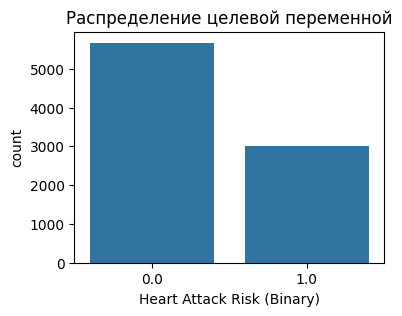

In [7]:
target_col = 'Heart Attack Risk (Binary)'  
# Распределение классов
class_dist = df[target_col].value_counts()
print("Распределение классов:")
print(class_dist)

# Визуализация
plt.figure(figsize=(4, 3))
sns.countplot(x=target_col, data=df)
plt.title('Распределение целевой переменной')
plt.show()

### Анализ признаков

In [8]:
# Исключим целевую переменную и бесполезные колонки:Unnamed: 0 и id
features = df.drop(columns=[target_col, 'Unnamed: 0', 'id'], errors='ignore')

# Определяем типы колонок
numeric_cols = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = features.select_dtypes(include=['object']).columns.tolist()

print(f"Всего признаков: {len(features.columns)}")
print(f"\nЧисловые признаки ({len(numeric_cols)}):")
print(numeric_cols)
print(f"\nКатегориальные признаки ({len(categorical_cols)}):")
print(categorical_cols)

Всего признаков: 25

Числовые признаки (24):
['Age', 'Cholesterol', 'Heart rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Blood sugar', 'CK-MB', 'Troponin', 'Systolic blood pressure', 'Diastolic blood pressure']

Категориальные признаки (1):
['Gender']


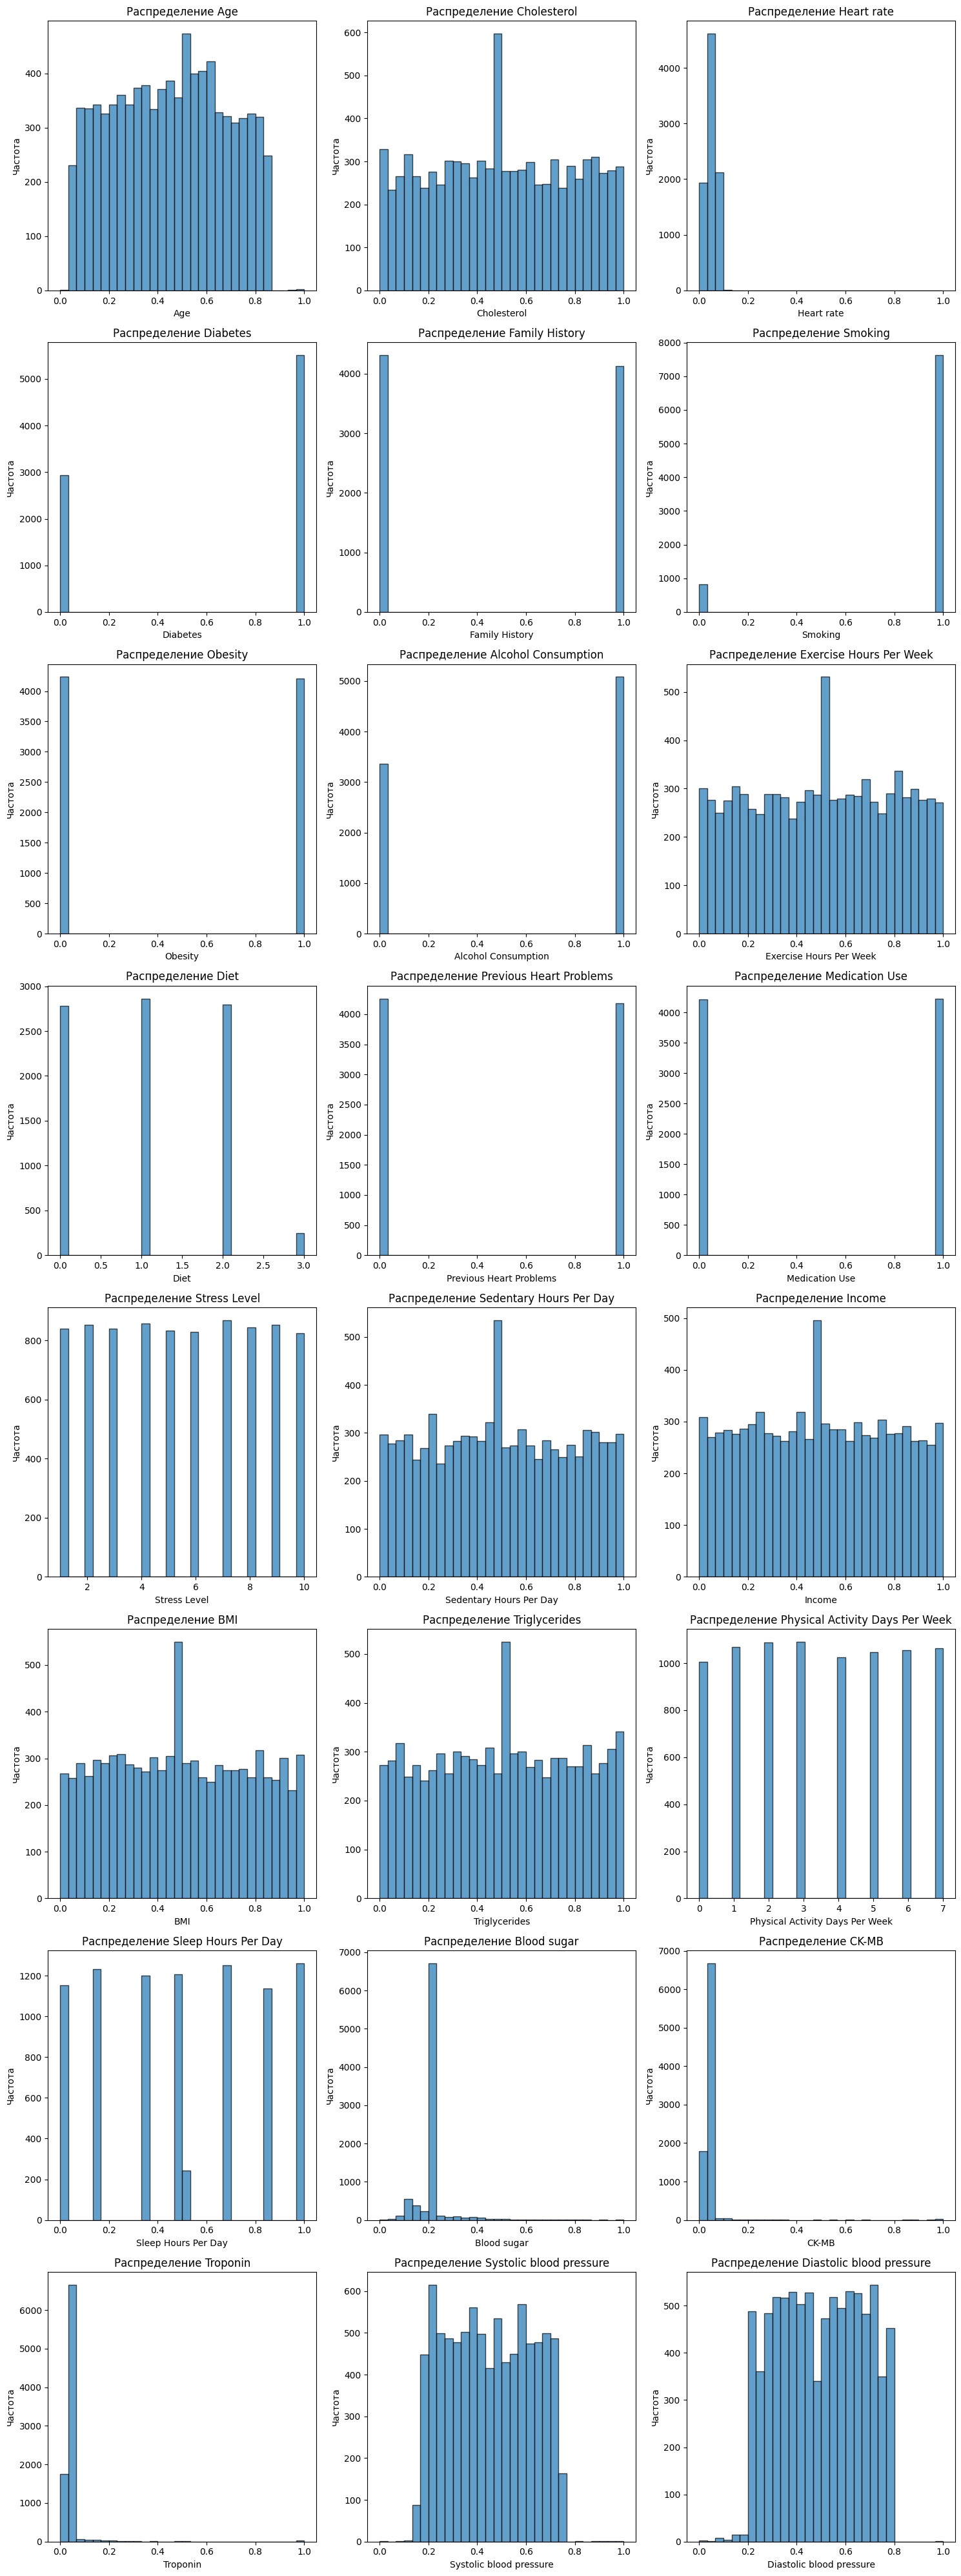

In [9]:
# Построим гистограммы распределения
# Числовых признаков много, поэтому необходимо построить сетку
n_cols = len(numeric_cols)
if n_cols > 0:
    n_rows = (n_cols + 2) // 3
    fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(15, 5*n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Распределение {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Частота')
    
    plt.tight_layout()
    plt.show()
else:
    print("Нет числовых признаков")

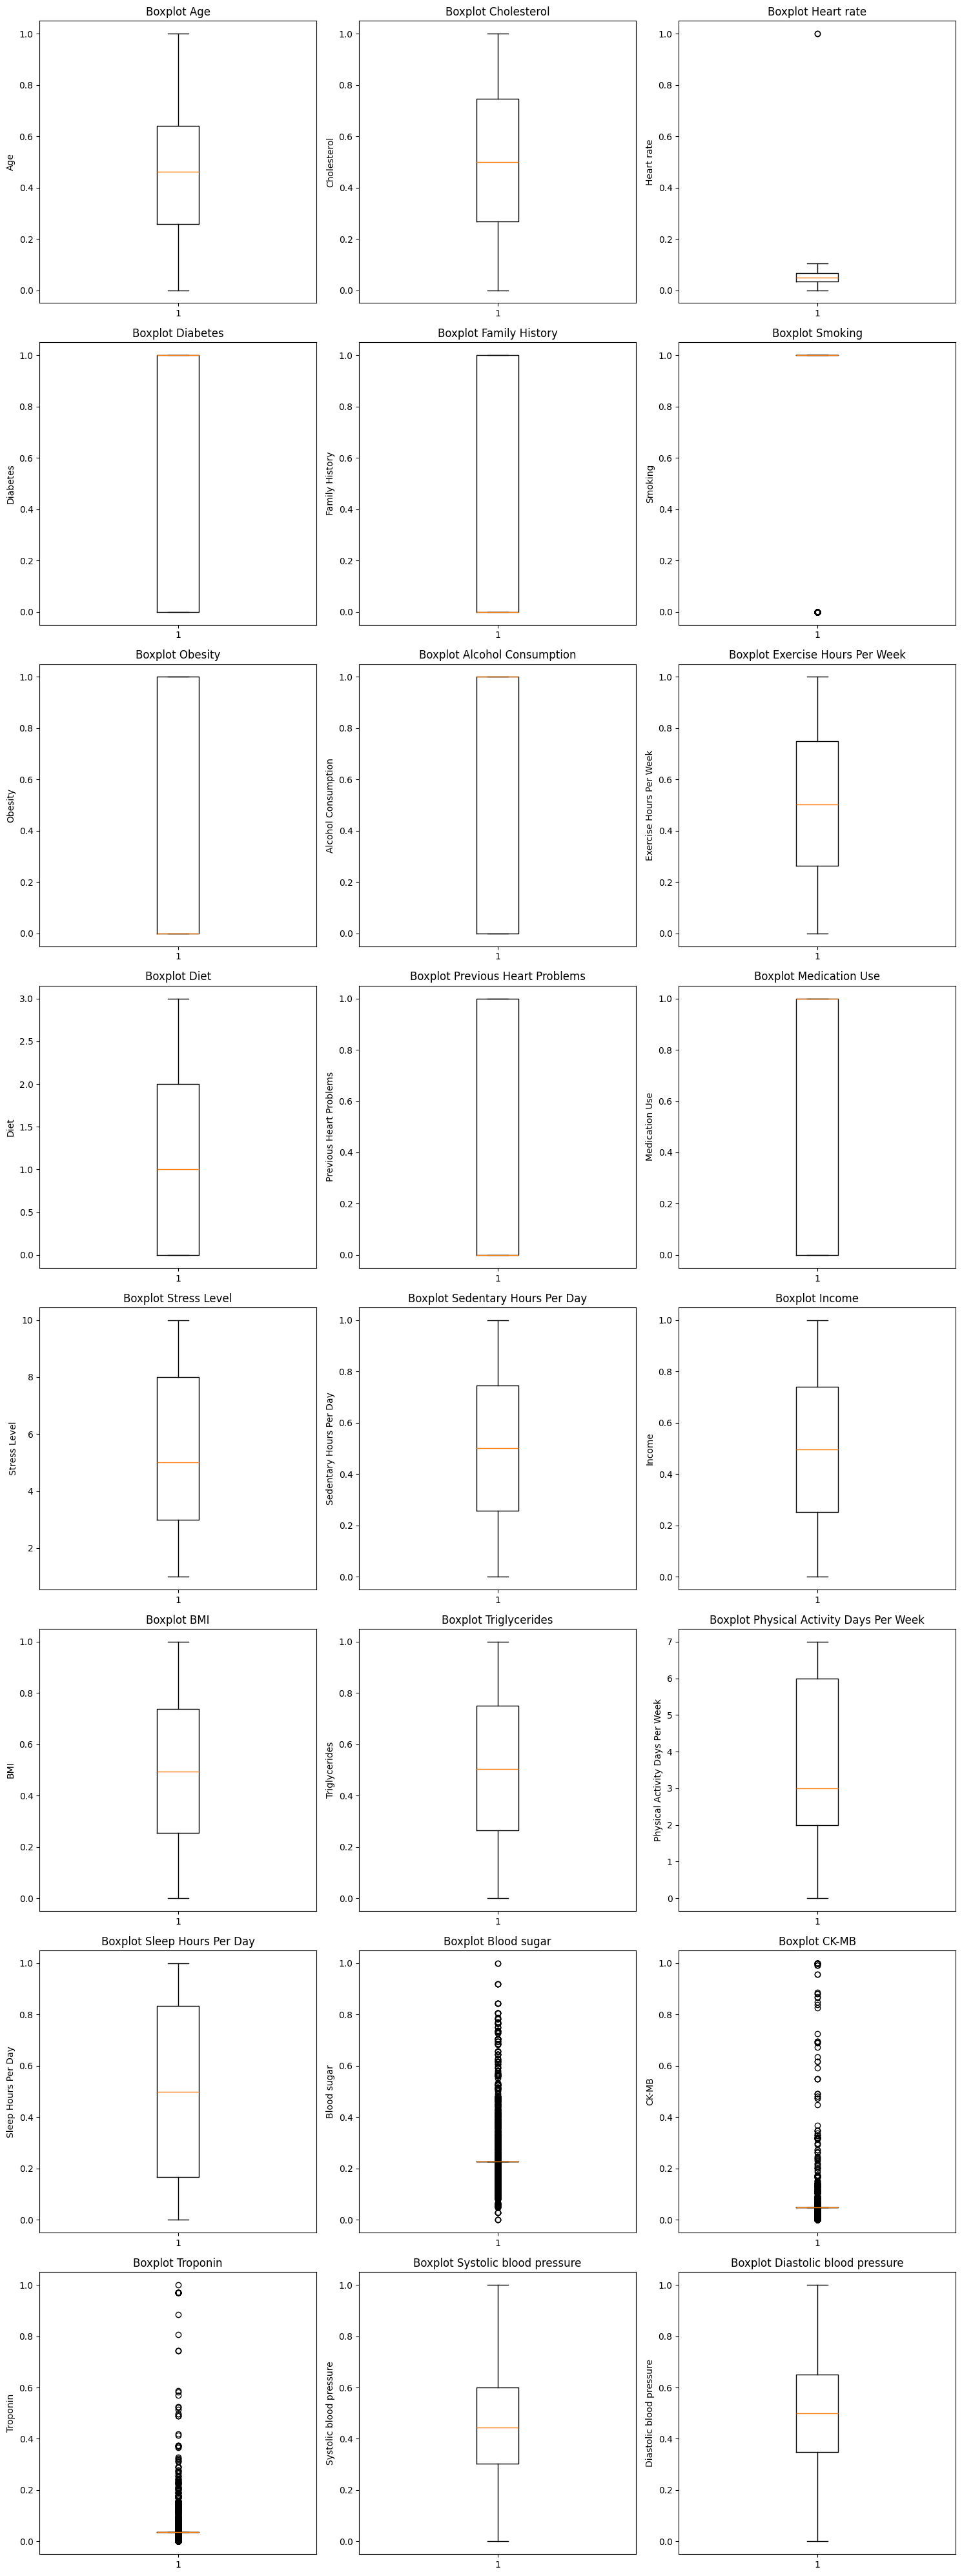

In [10]:
#Посмотрим наличие выбросов
if n_cols > 0:
    n_rows = (n_cols + 2) // 3
    fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(15, 5*n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        axes[i].boxplot(df[col].dropna())
        axes[i].set_title(f'Boxplot {col}')
        axes[i].set_ylabel(col)
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()


=== Gender ===
Уникальные значения:
Gender
Male      5882
Female    2560
1.0        156
0.0         87
Name: count, dtype: int64


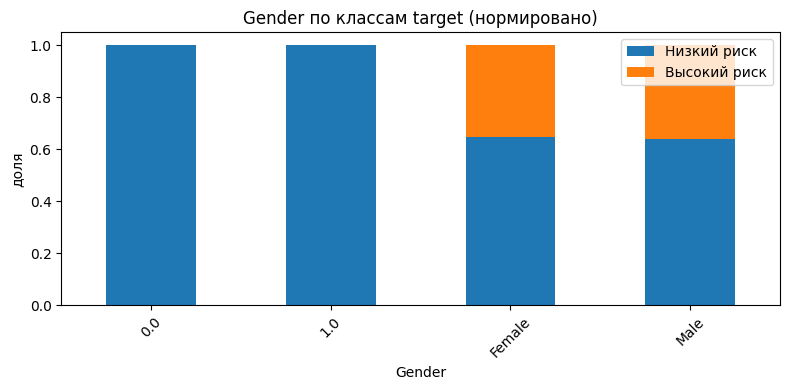

In [11]:
for col in categorical_cols:
    print(f"\n=== {col} ===")
    print("Уникальные значения:")
    print(df[col].value_counts())
    
    # Проверяем связь с целевой переменной
    if df[col].nunique() <= 10:  # если категорий не слишком много
        plt.figure(figsize=(8, 4))
        
        # Нормированное распределение по классам
        crosstab = pd.crosstab(df[col], df[target_col], normalize='index')
        crosstab.plot(kind='bar', stacked=True, ax=plt.gca())
        plt.title(f'{col} по классам target (нормировано)')
        plt.ylabel('доля')
        plt.legend(['Низкий риск', 'Высокий риск'])
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

### Корреляционный анализ

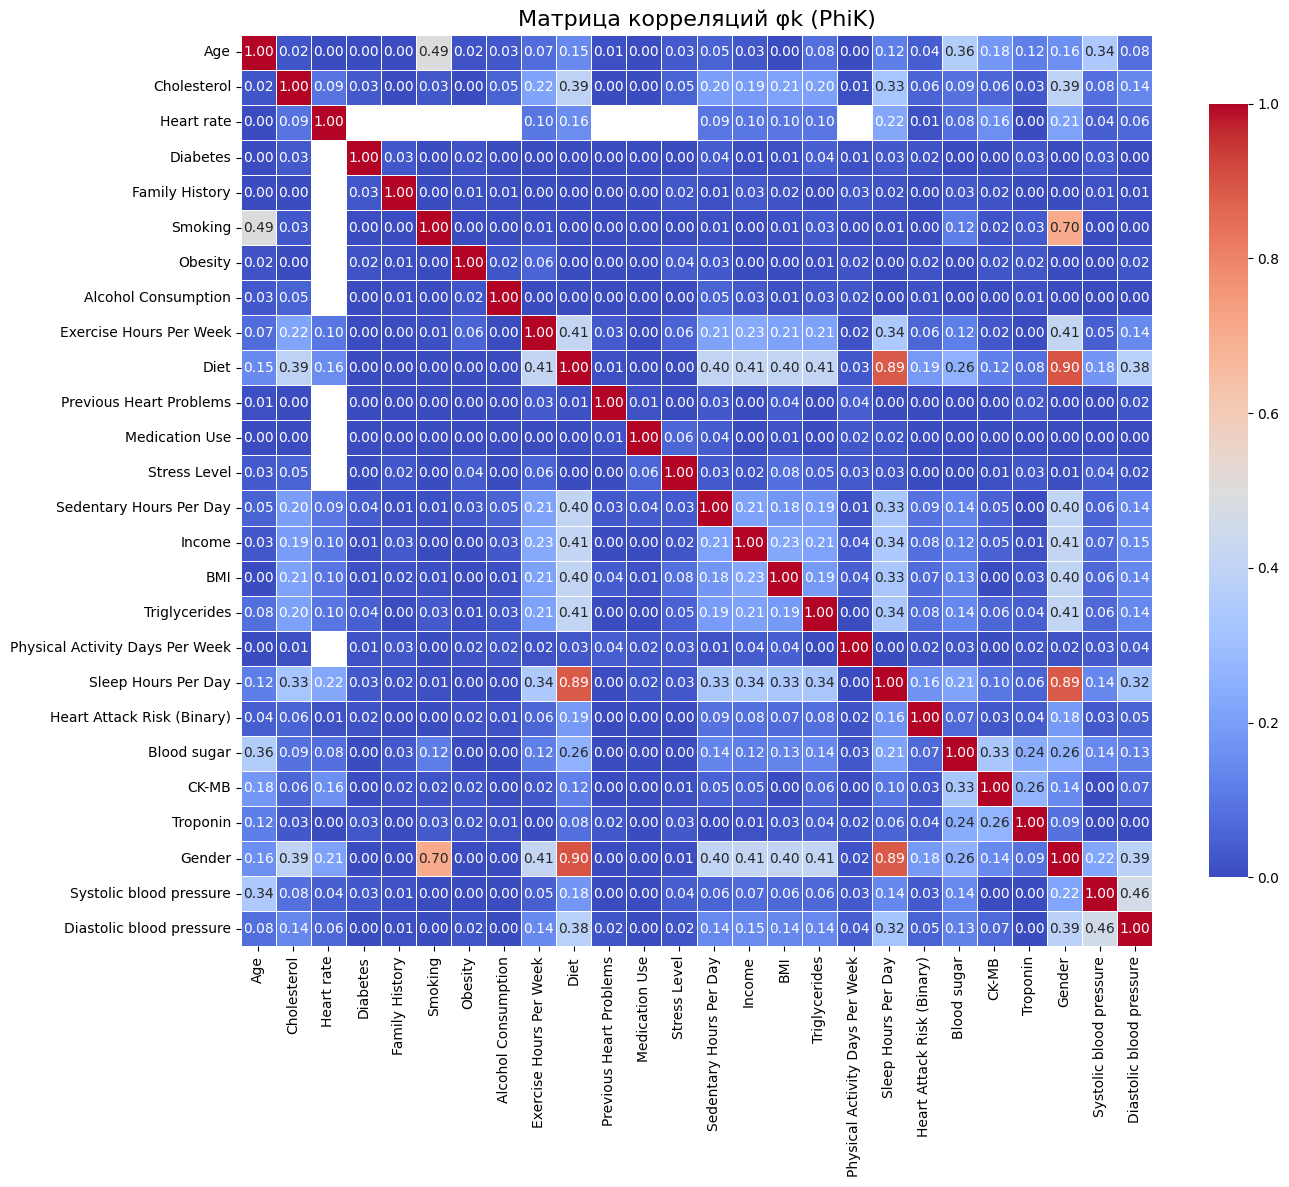

In [12]:
# Выберем все признаки (кроме id и Unnamed: 0) и целевую переменную
features_for_phik = df.drop(columns=['Unnamed: 0', 'id'], errors='ignore')

phik_matrix = features_for_phik.phik_matrix(interval_cols=numeric_cols)

plt.figure(figsize=(14, 12))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций φk (PhiK)', fontsize=16)
plt.tight_layout()
plt.show()

Diet: 0.1865 (слабая)
Gender: 0.1847 (слабая)
Sleep Hours Per Day: 0.1641 (слабая)
Sedentary Hours Per Day: 0.0870 (слабая)
Income: 0.0834 (слабая)
Triglycerides: 0.0819 (слабая)
BMI: 0.0715 (слабая)
Blood sugar: 0.0671 (слабая)
Exercise Hours Per Week: 0.0625 (слабая)
Cholesterol: 0.0575 (слабая)
Diastolic blood pressure: 0.0533 (слабая)
Age: 0.0413 (слабая)
Troponin: 0.0355 (слабая)
Systolic blood pressure: 0.0334 (слабая)
CK-MB: 0.0254 (слабая)
Diabetes: 0.0183 (слабая)
Physical Activity Days Per Week: 0.0178 (слабая)
Obesity: 0.0158 (слабая)
Alcohol Consumption: 0.0146 (слабая)
Heart rate: 0.0127 (слабая)
Medication Use: 0.0000 (слабая)
Previous Heart Problems: 0.0000 (слабая)
Smoking: 0.0000 (слабая)
Family History: 0.0000 (слабая)
Stress Level: 0.0000 (слабая)


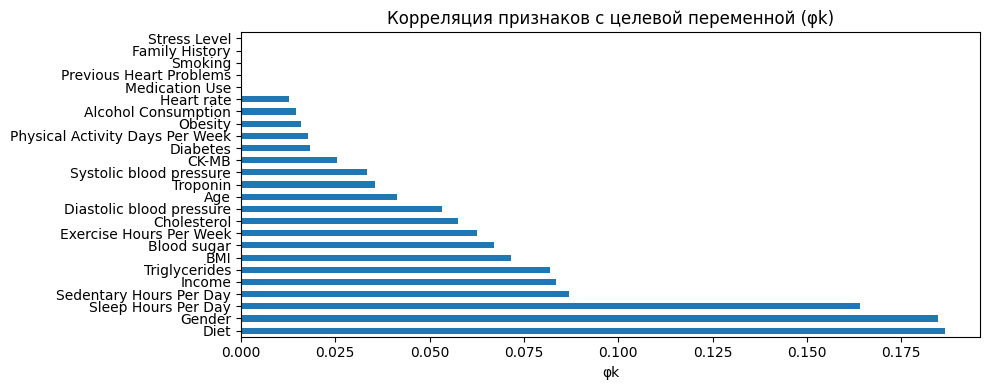

In [13]:
# Корреляция всех признаков с целевой переменной
target_corr_phik = phik_matrix[target_col].drop(target_col).sort_values(ascending=False)

for feature, corr in target_corr_phik.items():
    strength = "очень сильная" if corr > 0.7 else "сильная" if corr > 0.5 else "средняя" if corr > 0.3 else "слабая"
    print(f"{feature}: {corr:.4f} ({strength})")

# Визуализация
plt.figure(figsize=(10, 4))
target_corr_phik.plot(kind='barh')
plt.title('Корреляция признаков с целевой переменной (φk)')
plt.xlabel('φk')
plt.tight_layout()
plt.show()

In [14]:
# Найдём пары признаков с высокой корреляцией (> 0.75)
high_corr_pairs = []

for i in range(len(phik_matrix.columns)):
    for j in range(i+1, len(phik_matrix.columns)):
        col_i = phik_matrix.columns[i]
        col_j = phik_matrix.columns[j]
        corr_value = phik_matrix.iloc[i, j]
        
        if corr_value > 0.75 and col_i != target_col and col_j != target_col:
            high_corr_pairs.append((col_i, col_j, corr_value))
            print(f"{col_i} — {col_j}: φk = {corr_value:.4f}")

if not high_corr_pairs:
    print("Сильных корреляций между признаками не обнаружено")

Diet — Sleep Hours Per Day: φk = 0.8866
Diet — Gender: φk = 0.8951
Sleep Hours Per Day — Gender: φk = 0.8865


#### Выводы по исследовательскому анализу данных
Размер датасета: 8685 строк, 28 колонок
Целевая переменная: Heart Attack Risk (Binary)

##### Целевая переменная
- Распределение классов:
  - Класс 0 (низкий риск): 65 % 
  - Класс 1 (высокий риск): 35 %

##### Пропуски
В данных обнаружены пропуски- 243 в колонках  Diabetes, Family, HistorySmoking, Obesity, Alcohol Consumption, Previous Heart Problems, Medication Use, Stress Level, Physical Activity Days Per Week 

##### Выбросы
Явные выбросы в колонках Smoking, Heart rate.

##### Корреляция признаков
С таргетом у всех признаков слабая корреляция. Между собой коррелируют больше всего следубщие признаки:
Diet — Sleep Hours Per Day: φk = 0.8866
Diet — Gender: φk = 0.8951
Sleep Hours Per Day — Gender: φk = 0.8865

Дисбаланс классов, с которым столкнулись в результате исследовательского анализа, не критичен. Исходя из этого выберем метрику F1 или ROC-AUC. Пропуски можно заполнить.
Так как корреляции слабые , то необходимо использовать все признаки, но возможно, некоторые придётся исключить после обучения.

Gender — единственный категориальный признак (нужно разобраться только с заполнением данного признака, так как там 4 уникальных значения: Male, Female, 0, 1)

Unnamed: 0 — явно лишний, удалим

id — тоже удалим

## Предобработка данных

In [15]:
# Удаляем явно бесполезные колонки
cols_to_drop = ['Unnamed: 0', 'id']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
print(f"Осталось колонок: {df.shape[1]}")

Осталось колонок: 26


In [16]:
#Разберемся с уникальными значениями в Gender
print("Уникальные значения в Gender:")
print(df['Gender'].value_counts())

# Посмотрим на строки с необычными значениями
unusual_gender = df[~df['Gender'].isin(['Male', 'Female'])]

Уникальные значения в Gender:
Gender
Male      5882
Female    2560
1.0        156
0.0         87
Name: count, dtype: int64


In [17]:
# Если хочешь автоматически определить, что скрывается за 0 и 1:
# Посмотрим средний возраст и target для этих групп
print("\nСтатистика для групп:")
for val in ['0', '1', 'Male', 'Female']:
    subset = df[df['Gender'] == val]
    print(f"\n{val}:")
    print(f"  Количество: {len(subset)}")
    print(f"  Средний возраст: {subset['Age'].mean():.2f}")
    print(f"  Доля высокого риска: {subset['Heart Attack Risk (Binary)'].mean():.2%}")


Статистика для групп:

0:
  Количество: 0
  Средний возраст: nan
  Доля высокого риска: nan%

1:
  Количество: 0
  Средний возраст: nan
  Доля высокого риска: nan%

Male:
  Количество: 5882
  Средний возраст: 0.45
  Доля высокого риска: 35.92%

Female:
  Количество: 2560
  Средний возраст: 0.44
  Доля высокого риска: 35.16%


In [18]:
# Найдём строки с пропусками в других колонках
rows_with_missing = df[df['Diabetes'].isna()].index
print(f"Строк с пропусками в Diabetes: {len(rows_with_missing)}")

# Найдём строки с нестандартным Gender
unusual_gender = df[~df['Gender'].isin(['Male', 'Female'])].index
print(f"Строк с нестандартным Gender: {len(unusual_gender)}")

# Проверим, совпадают ли эти множества
if len(rows_with_missing) == len(unusual_gender):
    if set(rows_with_missing) == set(unusual_gender):
        print("Это одни и те же 243 строки!")
    else:
        print("❌ Множества не совпадают")
else:
    print(f"❌ Разный размер: {len(rows_with_missing)} vs {len(unusual_gender)}")

Строк с пропусками в Diabetes: 243
Строк с нестандартным Gender: 243
Это одни и те же 243 строки!


In [19]:
# Удалим строки с незаполненными данными
# Находим строки с нестандартным Gender (где не Male и не Female)
mask_unusual = ~df['Gender'].isin(['Male', 'Female'])
print(f"Найдено проблемных строк: {mask_unusual.sum()}")

# Удаляем эти строки
df_clean = df[~mask_unusual].copy()
print(f"\nПосле удаления: {len(df_clean)} строк")

# Сбрасываем индекс
df_clean = df_clean.reset_index(drop=True)

Найдено проблемных строк: 243

После удаления: 8442 строк


In [20]:
# Проверяем, есть ли пропуски в остальных данных
missing = df_clean.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    print("Остались пропуски в колонках:")
    print(missing)
else:
    print("Пропусков больше нет!")

Пропусков больше нет!


In [21]:
print("Распределение Gender после очистки:")
print(df_clean['Gender'].value_counts())

# Кодируем Gender в числа
from sklearn.preprocessing import LabelEncoder
le_gender = LabelEncoder()
df_clean['Gender_encoded'] = le_gender.fit_transform(df_clean['Gender'])

print("\nКодирование Gender:")
for cat, code in zip(le_gender.classes_, range(len(le_gender.classes_))):
    print(f"{cat} -> {code}")

# Можно удалить исходную колонку Gender
df_clean = df_clean.drop(columns=['Gender'])

Распределение Gender после очистки:
Gender
Male      5882
Female    2560
Name: count, dtype: int64

Кодирование Gender:
Female -> 0
Male -> 1


In [23]:
#Разделим на признаки и целевую переменную
target_col = 'Heart Attack Risk (Binary)'
y = df_clean[target_col]
X = df_clean.drop(columns=[target_col])

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"Распределение target:\n{y.value_counts(normalize=True)}")

Размер X: (8442, 25)
Размер y: (8442,)
Распределение target:
Heart Attack Risk (Binary)
0.0    0.643094
1.0    0.356906
Name: proportion, dtype: float64


In [27]:
# Произведем масштабирование признаков
# Определяем типы признаков
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Определяем бинарные признаки (0/1), которые не требуют масштабирования
binary_features = []
for col in numeric_features:
    if len(X[col].unique()) <= 2:
        binary_features.append(col)

# Признаки для масштабирования
features_to_scale = [col for col in numeric_features if col not in binary_features]

# Масштабирование
scaler = StandardScaler()
X_scaled = X.copy()

In [29]:
# Разделим данные на тренировочные и валидационные
# Разделяем данные
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train размер: {X_train.shape}")
print(f"Val размер: {X_val.shape}")

Train размер: (6753, 25)
Val размер: (1689, 25)


In [31]:
# Сохраним данные
# Создаём папки для сохранения
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Сохраняем scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler сохранён")

# Сохраняем обработанные данные
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_val.to_csv('../data/processed/X_val.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_val.to_csv('../data/processed/y_val.csv', index=False)
print("Данные сохранены")

# Сохраняем список признаков для будущего использования
feature_names = X_train.columns.tolist()
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)
print("Список признаков сохранён")

Scaler сохранён
Данные сохранены
Список признаков сохранён


In [33]:
#Создадим класс Preprocessor 
class DataPreprocessor:
    def __init__(self):
        self.scaler = None
        self.features_to_scale = None
        self.binary_features = None
        self.all_features = None
        self.le_gender = None
        
    def fit(self, X, y=None):
        # Определяем типы признаков
        numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
        
        # Бинарные признаки
        self.binary_features = []
        for col in numeric_features:
            if len(X[col].unique()) <= 2:
                self.binary_features.append(col)
        
        # Признаки для масштабирования
        self.features_to_scale = [col for col in numeric_features if col not in self.binary_features]
        
        # Обучаем scaler
        if self.features_to_scale:
            self.scaler = StandardScaler()
            self.scaler.fit(X[self.features_to_scale])
        
        # Сохраняем список всех признаков
        self.all_features = X.columns.tolist()
        
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        
        # Масштабирование
        if self.scaler and self.features_to_scale:
            # Проверяем, что все нужные колонки есть
            missing_cols = [col for col in self.features_to_scale if col not in X.columns]
            if missing_cols:
                raise ValueError(f"Отсутствуют колонки: {missing_cols}")
            
            X_transformed[self.features_to_scale] = self.scaler.transform(X[self.features_to_scale])
        
        return X_transformed
    
    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.transform(X)

# Тестируем класс
preprocessor = DataPreprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print(f"X_train после обработки: {X_train_processed.shape}")
print(f"X_val после обработки: {X_val_processed.shape}")

# Сохраняем препроцессор
with open('../models/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

X_train после обработки: (6753, 25)
X_val после обработки: (1689, 25)


В рамках предобработки данных удалено 243 проблемных строки, а также удалены лишние признаки. Пропусков в данных на текущий момент 0. 17 признаков отмасштабированы.